# Strategic Exploratory Data Analysis — ModCloth (Start2Impact)

## Objective

The goal of this analysis is to transform customer review data (fit feedback, size, product category, quality ratings and body measurements) into actionable insights for an apparel e-commerce environment.

In particular, the analysis focuses on identifying patterns of **fit mismatch** that could inform sizing guidance, assortment decisions and customer communication strategies.

## Guiding Questions

- Where does **fit mismatch** (small / large) concentrate across product categories and sizes?
- Is fit mismatch associated with **lower perceived product quality**?
- Do distinct **user profiles** emerge from the data that could guide merchandising and communication strategies?

> **Note:** This notebook uses the **clean dataset** generated in `01_data_understanding.ipynb` (`data/processed/modcloth_clean.parquet`).

## Research Question

Can customer reviews be used to identify patterns of sizing mismatch across categories, sizes and user profiles in order to reduce return risk in an apparel e-commerce environment?

### Analytical Hypotheses

H1 — mismatch rate varies across product categories  
H2 — mismatch rate varies across sizes  
H3 — mismatch rate varies across user height buckets  
H4 — mismatch is associated with lower perceived product quality


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 50)


def find_project_root(start: Path | None = None) -> Path:
    """Ritorna la root del progetto cercando una cartella che contenga sia /data sia /src."""
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / "data").exists() and (p / "src").exists():
            return p
    return start


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.metrics import mismatch_rate, mismatch_table
from src.clustering import build_user_features, prepare_clustering_matrix, evaluate_k_range, run_kmeans_user_clustering
from src.viz import plot_cluster_radar, plot_cluster_parallel, plot_cluster_pca, plot_bar_pct

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "modcloth_clean.parquet"
df = pd.read_parquet(DATA_PATH)

print("Project root:", PROJECT_ROOT.name)
print("Loaded:", DATA_PATH.relative_to(PROJECT_ROOT))
print("Shape:", df.shape)

df.head(3)


Project root: Manipulation and Visualization
Loaded: data/processed/modcloth_clean.parquet
Shape: (78655, 21)


,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text,mismatch,height_cm,height_bucket
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN,1,167.6,160-170
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN,1,157.5,<160
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN,1,170.2,170-180


## Preliminary Correlation Analysis (Spearman)

Before moving into the specific analyses, we first examine the **correlations between the main variables**.

This correlation matrix serves as an **exploratory guide**, helping identify potential relationships that may deserve further investigation in the following sections.

**Note:** correlation does not imply causation.

In [ ]:
spearman_cols = [
    "mismatch",
    "size",
    "quality",
    "height_cm",
]

spearman_df = df[spearman_cols].dropna()

corr = spearman_df.corr(method="spearman")

fig = px.imshow(
    corr,
    text_auto=".2f",
    aspect="auto",
    color_continuous_scale="RdBu_r",
    title="Spearman correlation — core variables",
)

fig.show()


In [2]:
mr = mismatch_rate(df)
print(f"Mismatch rate complessivo: {mr:.3f} ({mr*100:.1f}%)")


Mismatch rate complessivo: 0.315 (31.5%)


,fit,small,large,mismatch,n
category,,,,,
new,0.670766,0.191004,0.138230,0.329234,20408
tops,0.663245,0.132814,0.203941,0.336755,19388
dresses,0.727965,0.135961,0.136075,0.272035,17608
bottoms,0.697599,0.166953,0.135447,0.302401,14537
outerwear,0.663459,0.145818,0.190723,0.336541,4053
sale,0.630987,0.197418,0.171595,0.369013,2401
wedding,0.788462,0.050000,0.161538,0.211538,260


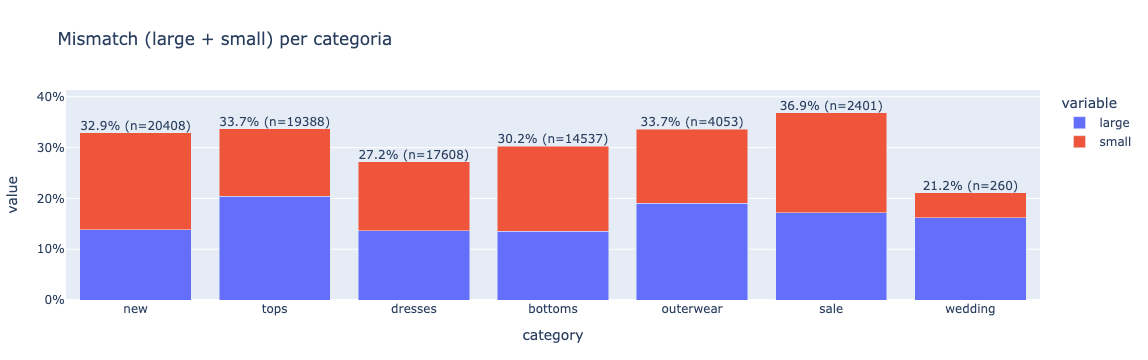

In [3]:
cat_tbl = mismatch_table(df, by="category")
display(cat_tbl)

# Barplot riusabile: mismatch totale per categoria con etichetta % + n
fig = plot_bar_pct(
    cat_tbl.reset_index(),
    x="category",
    y=["large", "small"],
    n_col="n",
    title="Mismatch (large + small) per categoria",
)
fig.show()


In [4]:
size_tbl = mismatch_table(df, by="size")
display(size_tbl.sort_values("mismatch", ascending=False).head(10))

,fit,small,large,mismatch,n
size,,,,,
27,0.511364,0.295455,0.193182,0.488636,88
30,0.524590,0.262295,0.213115,0.475410,61
38,0.547210,0.223176,0.229614,0.452790,1398
32,0.565129,0.205900,0.228972,0.434871,3424
24,0.589744,0.213675,0.196581,0.410256,117
26,0.605175,0.177960,0.216865,0.394825,5372
13,0.610989,0.239560,0.149451,0.389011,455
18,0.620690,0.125000,0.254310,0.379310,232
20,0.624641,0.111302,0.264056,0.375359,6972


In [5]:
height_tbl = mismatch_table(df, by="height_bucket")
display(height_tbl)

,fit,small,large,mismatch,n
height_bucket,,,,,
160-170,0.687692,0.158939,0.153369,0.312308,33214
170-180,0.672880,0.166492,0.160628,0.327120,22854
<160,0.697588,0.142919,0.159494,0.302412,20935
180+,0.661622,0.179177,0.159201,0.338378,1652


In [6]:
quality_tbl = df.groupby("mismatch")["quality"].mean()
quality_tbl

mismatch
0    4.081099
1    3.650937
Name: quality, dtype: float64

## Relationship Between Fit Mismatch and Perceived Product Quality

Average product ratings tend to be lower when the garment does not fit correctly.

The observed difference (~0.43 points on a 1–5 scale) is **associated with fit mismatch** and supports the idea that sizing issues are linked to lower perceived customer satisfaction.

**Methodological note:** this evidence is correlational. Without an experimental design or stronger controls, we cannot conclude a causal relationship between fit mismatch and product ratings.

In [6]:
combo_tbl = (
    df
    .groupby(["category", "size"])
    .agg(
        mismatch_rate=("mismatch", "mean"),
        n=("mismatch", "count")
    )
    .reset_index()
)

# Filtriamo combinazioni troppo piccole (rumore statistico)
combo_tbl = combo_tbl[combo_tbl["n"] >= 100]

combo_tbl.sort_values("mismatch_rate", ascending=False).head(15)

,category,size,mismatch_rate,n
73,outerwear,32,0.537688,199
19,bottoms,32,0.512445,683
111,tops,38,0.493124,509
92,sale,26,0.492147,191
71,outerwear,20,0.482480,371
87,sale,15,0.479839,248
94,sale,32,0.472868,129
39,dresses,32,0.447619,525
72,outerwear,26,0.445161,310
65,new,38,0.441913,439


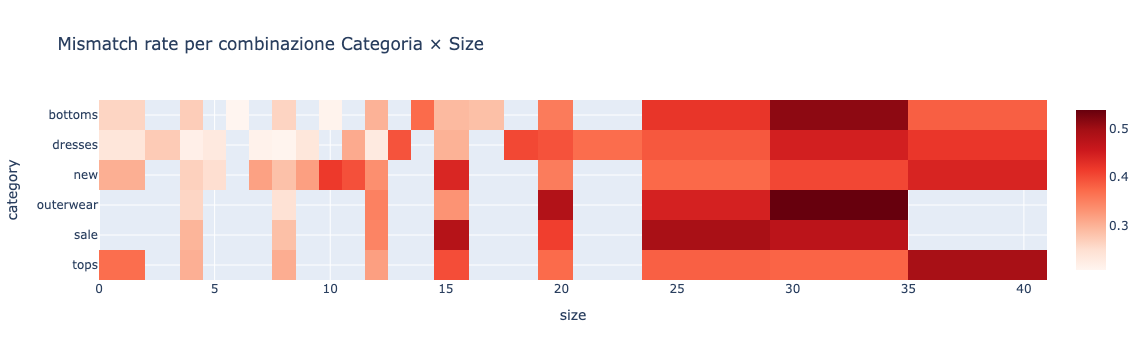

In [7]:
heatmap_data = combo_tbl.pivot(
    index="category",
    columns="size",
    values="mismatch_rate"
)

fig = px.imshow(
    heatmap_data,
    aspect="auto",
    color_continuous_scale="Reds",
    title="Mismatch rate per combinazione Categoria × Size"
)

fig.show()


### Why We Filter Combinations with Few Observations (n ≥ 100)

When analyzing *Category × Size* (or *Size × Height*), many combinations contain only a small number of observations. In those cases, the estimated mismatch rate becomes **statistically unstable** and may simply reflect noise.

For this reason, we apply a minimum threshold (`n ≥ 100`) before building heatmaps and rankings.

This choice helps to:

- increase the statistical reliability of the estimated percentages;
- make the visualizations easier to interpret (fewer noisy cells);
- focus the analysis on segments that are truly relevant for assortment and sizing decisions.

In [8]:
size_height_tbl = (
    df
    .groupby(["size", "height_bucket"])
    .agg(
        mismatch_rate=("mismatch", "mean"),
        n=("mismatch", "count")
    )
    .reset_index()
)

# Filtriamo combinazioni troppo piccole
size_height_tbl = size_height_tbl[size_height_tbl["n"] >= 100]

size_height_tbl.sort_values("mismatch_rate", ascending=False).head(15)

,size,height_bucket,mismatch_rate,n
95,38,<160,0.464481,183
96,38,160-170,0.456942,569
92,32,160-170,0.453497,1387
94,32,180+,0.447205,161
97,38,170-180,0.445026,573
91,32,<160,0.429984,607
52,14,160-170,0.424460,139
82,26,180+,0.423963,217
48,13,160-170,0.418605,172
93,32,170-180,0.415288,1269


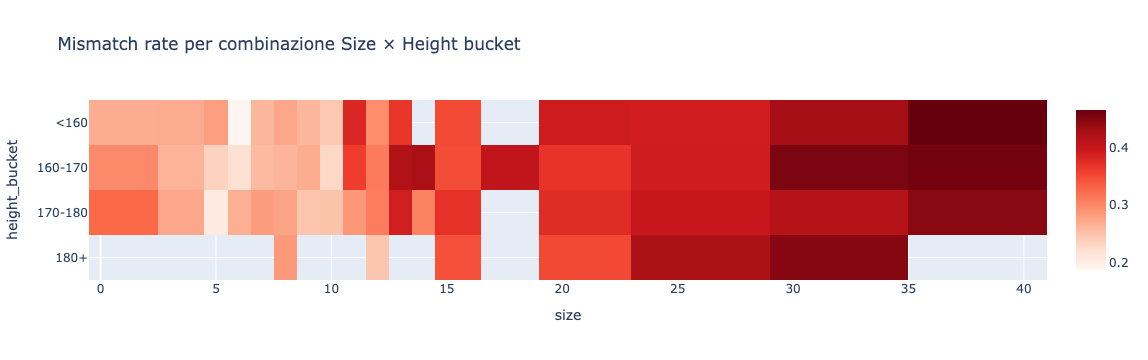

In [9]:
heatmap_sh = size_height_tbl.pivot(
    index="height_bucket",
    columns="size",
    values="mismatch_rate"
)

fig = px.imshow(
    heatmap_sh,
    aspect="auto",
    color_continuous_scale="Reds",
    title="Mismatch rate per combinazione Size × Height bucket"
)

fig.show()


### Operational Reading of the *Size × Height Bucket* Heatmap

This view helps assess whether **height introduces a systematic effect on fit mismatch while holding size constant**.

If mismatch remains high across all height segments, the primary driver is likely **size-related** (for example, garment grading or overall fit structure).

Conversely, if mismatch increases within a specific height bucket, it could justify introducing **height-conditioned sizing recommendations**.

### Interpretation — Size × Height Bucket

The analysis of the *Size × Height bucket* combination shows that mismatch rates remain relatively stable across the different height segments.

Extreme sizes (e.g., 26, 32, 38) display consistently higher mismatch rates across all height buckets, with no clear evidence of a height-specific effect.

This suggests that the main driver of mismatch is the **size structure of the garments** (grading or garment proportions) rather than the customer's height.

As a result, the potential risk of returns or dissatisfaction appears to be **size-driven rather than height-driven**.

In [10]:
# Separiamo i due gruppi
quality_fit = df[df["mismatch"] == 0]["quality"].dropna()
quality_mismatch = df[df["mismatch"] == 1]["quality"].dropna()

# Welch t-test perchè popolazioni possibili varianze diverse
t_stat, p_value = stats.ttest_ind(
    quality_fit,
    quality_mismatch,
    equal_var=False
)

print("Media quality - Fit corretto:", quality_fit.mean())
print("Media quality - Mismatch:", quality_mismatch.mean())
print("Differenza media:", quality_fit.mean() - quality_mismatch.mean())
print("t-statistic:", t_stat)
print("p-value:", p_value)


Media quality - Fit corretto: 4.08109863598404
Media quality - Mismatch: 3.6509369055809624
Differenza media: 0.43016173040307804
t-statistic: 55.19444428492353
p-value: 0.0


In [11]:
# Aggregazione per utente (feature engineering a livello user)
user_features = build_user_features(df)

print("User-level dataset shape:", user_features.shape)
user_features.head()


User-level dataset shape: (45407, 8)


,user_id,n_reviews,mismatch_rate,avg_quality,avg_height,dominant_size,dominant_category,category_diversity
0,46,1,0.0,5.00,160.0,4,tops,1
1,55,1,0.0,2.00,157.5,32,bottoms,1
2,66,4,0.5,3.75,170.2,12,new,3
3,104,2,0.0,4.00,162.6,8,outerwear,2
4,111,2,0.0,5.00,167.6,15,tops,1


## User Segmentation — Objective and Methodology

The analysis so far suggests that fit mismatch is primarily **size-driven**.

To better understand user behavior, we aggregate the data at the **user level**.

The goal is to identify groups of users with similar behavioral patterns in terms of:

- mismatch rate
- perceived product quality
- average reported height
- dominant size
- category diversity
- number of reviews written

In [13]:
user_features.describe()

,user_id,n_reviews,mismatch_rate,avg_quality,avg_height,dominant_size,category_diversity
count,45407.000000,45407.000000,45407.000000,45363.000000,45407.000000,45407.000000,45407.000000
mean,498900.935825,1.732222,0.312701,3.957535,165.609298,11.830224,1.391371
std,287458.080926,1.584104,0.418606,0.912871,6.588962,7.883870,0.747663
min,46.000000,1.000000,0.000000,1.000000,142.200000,1.000000,1.000000
25%,250953.000000,1.000000,0.000000,3.000000,160.000000,8.000000,1.000000
50%,498638.000000,1.000000,0.000000,4.000000,165.100000,10.000000,1.000000
75%,746661.000000,2.000000,0.666667,5.000000,170.200000,15.000000,2.000000
max,999972.000000,27.000000,1.000000,5.000000,198.100000,38.000000,6.000000


In [14]:
print("Numero utenti unici:", user_features["user_id"].nunique())
print("Utenti con >5 recensioni:", (user_features["n_reviews"] > 5).sum())

Numero utenti unici: 45407
Utenti con >5 recensioni: 1473


## Preparing Data for Clustering (Key Design Choices)

Clustering only makes sense if the user-level features are **sufficiently stable**.

A user with only one review will have a `mismatch_rate` equal to either 0 or 1 by definition.  
This provides very little information and introduces a large amount of noise into the segmentation.

For this reason, we restrict the clustering analysis to users with at least **3 reviews**.

This choice helps to:

- reduce variance driven purely by chance;
- obtain more robust and interpretable clusters;
- retain a sufficiently large sample of users for the analysis.

## Selected Features and Standardization

For clustering, we use features that capture both **user behavior** and **fit-related friction**:

- `mismatch_rate` (sizing issues)
- `avg_quality` (perceived satisfaction)
- `n_reviews` (user engagement)
- `category_diversity` (breadth of purchases)
- `dominant_size` and `avg_height` (typical body / fit profile)

We standardize the features using **z-score normalization** because they are measured on different scales (centimeters, percentages and counts).

Since **KMeans is distance-based**, failing to scale the variables would cause features with larger numerical ranges to dominate the clustering results.

To ensure comparability across features, variables are standardized before clustering. 
Without scaling, variables with larger numerical ranges (e.g., height) could dominate the distance calculations used by KMeans.

Clustering is performed using **KMeans**, which groups observations by minimizing **within-cluster variance**.

The number of clusters is selected using the **Elbow Method**, which evaluates how the within-cluster variance decreases as the number of clusters increases.

In [15]:
# Preparazione matrice per clustering (utenti con almeno 3 recensioni)
MIN_REVIEWS = 3
FEATURE_COLS = [
    "mismatch_rate",
    "avg_quality",
    "avg_height",
    "dominant_size",
    "category_diversity",
    "n_reviews",
]

user_cluster = user_features[user_features["n_reviews"] >= MIN_REVIEWS].copy()
cluster_features, X_scaled, scaler = prepare_clustering_matrix(
    user_cluster=user_cluster,
    feature_cols=FEATURE_COLS,
)

print("Utenti per clustering:", user_cluster.shape[0])
print("Shape matrice clustering:", cluster_features.shape)

# Valutazione k (metriche interne + inertia)
k_eval = evaluate_k_range(X_scaled, k_range=range(2, 10), random_state=42)
display(k_eval)


Utenti per clustering: 7102
Shape matrice clustering: (7102, 6)


,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,35412.500469,0.222286,1443.458987,1.785570
1,3,29900.650303,0.182533,1508.963269,1.773533
2,4,26583.035426,0.180537,1426.644082,1.619234
3,5,24302.483526,0.160553,1336.726490,1.564720
4,6,22566.407811,0.158698,1260.669225,1.516362
5,7,21124.177240,0.160824,1202.869651,1.496264
6,8,20165.032975,0.159181,1128.113193,1.536034
7,9,19433.803376,0.148841,1057.464070,1.556780


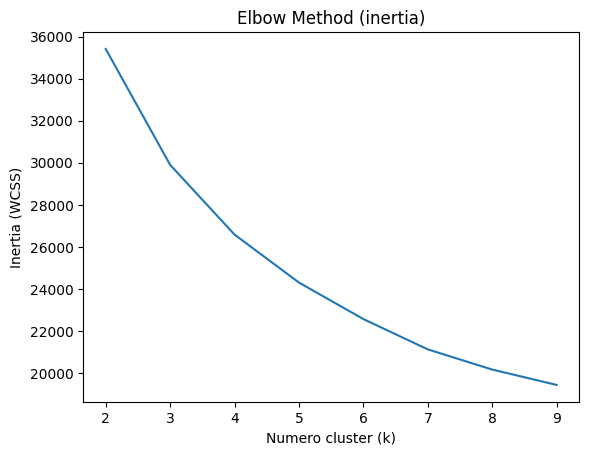

In [16]:
# Elbow plot (inertia) basato sulla tabella k_eval
plt.plot(k_eval["k"], k_eval["inertia"])
plt.xlabel("Numero cluster (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method (inertia)")
plt.show()


### Choosing *k*: Avoiding Arbitrary Decisions

KMeans requires specifying the number of clusters `k`.  
To avoid an arbitrary choice, we rely on several complementary criteria.

- We use the **Elbow Method** (inertia) as the primary guide, looking for the **inflection point** beyond which additional clusters produce diminishing improvements.
- We compute internal validation metrics (**Silhouette**, **Calinski–Harabasz**, **Davies–Bouldin**) as **sanity checks**, rather than as an automatic optimization rule.
- The final choice also considers **interpretability and actionability**: we prefer a small number of clusters that can be translated into concrete operational levers (sizing UX, assortment decisions, customer communication).

*Note:* while the silhouette score peaks at `k = 2`, suggesting two broad groups, choosing `k = 4` provides a level of segmentation that is more informative and actionable for business decisions.

In [17]:
# Scelta finale k
K = 4

clustered_df, cluster_profile_labeled, kmeans = run_kmeans_user_clustering(
    user_cluster=user_cluster,
    X_scaled=X_scaled,
    cluster_features=cluster_features,
    k=K,
    random_state=42,
    feature_cols=FEATURE_COLS,
)

display(cluster_profile_labeled.sort_values("users", ascending=False))

# Salvataggi per riuso (dataset processed)
OUT_DIR = PROJECT_ROOT / "data" / "processed"
OUT_DIR.mkdir(parents=True, exist_ok=True)

clustered_df.to_csv(OUT_DIR / "user_cluster_features_k4.csv", index=False)
cluster_profile_labeled.to_csv(OUT_DIR / "cluster_profile_k4.csv", index=True)

print("Salvati:")
print("-", OUT_DIR / "user_cluster_features_k4.csv")
print("-", OUT_DIR / "cluster_profile_k4.csv")


,users,mismatch_rate,avg_quality,avg_height,dominant_size,category_diversity,n_reviews,dominant_size_mode,dominant_category_mode,persona
cluster,,,,,,,,,,
0,2777,0.129,4.271,164.801,8.938,2.436,3.737,8,bottoms,Fit-driven soddisfatti
3,2005,0.544,3.418,165.343,10.205,2.446,3.698,12,bottoms,A rischio mismatch (friction)
1,1263,0.377,3.957,168.917,26.309,2.537,3.977,26,tops,Tolleranti al mismatch
2,1057,0.308,3.939,165.982,13.419,4.106,8.837,12,tops,Esigenti ma coerenti


Salvati:
- /Users/davidealoisi/Desktop/CAREER/MASTER/PYTHON/Manipulation and Visualization/data/processed/user_cluster_features_k4.csv
- /Users/davidealoisi/Desktop/CAREER/MASTER/PYTHON/Manipulation and Visualization/data/processed/cluster_profile_k4.csv


## Cluster Visualization (Plotly)

To make the segmentation more interpretable and actionable, we add three complementary visualizations:

- **Radar chart (normalized):** compares the cluster profiles across the main features.
- **Parallel coordinates:** enables multi-feature comparison and helps highlight potential trade-offs between variables.
- **PCA scatter (2D):** projects the scaled feature space into two dimensions to visualize separation or overlap between clusters.

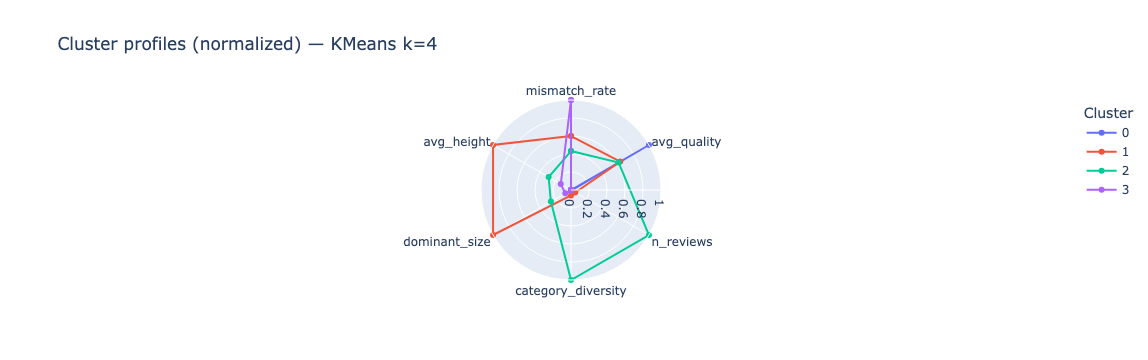

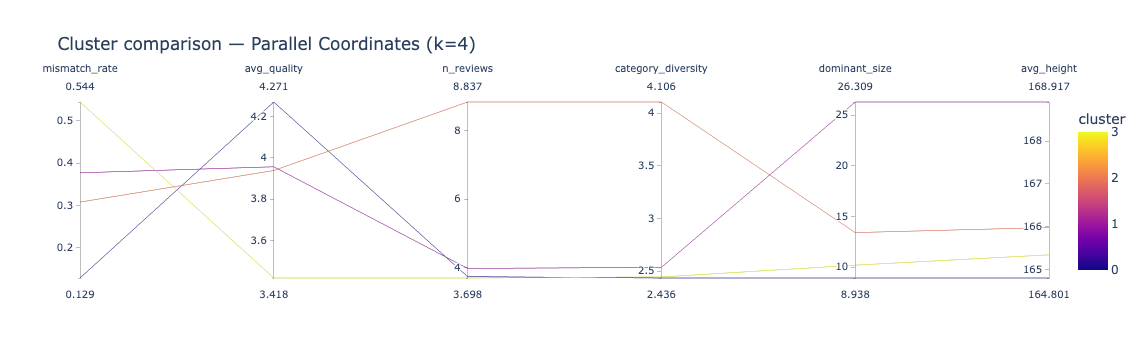

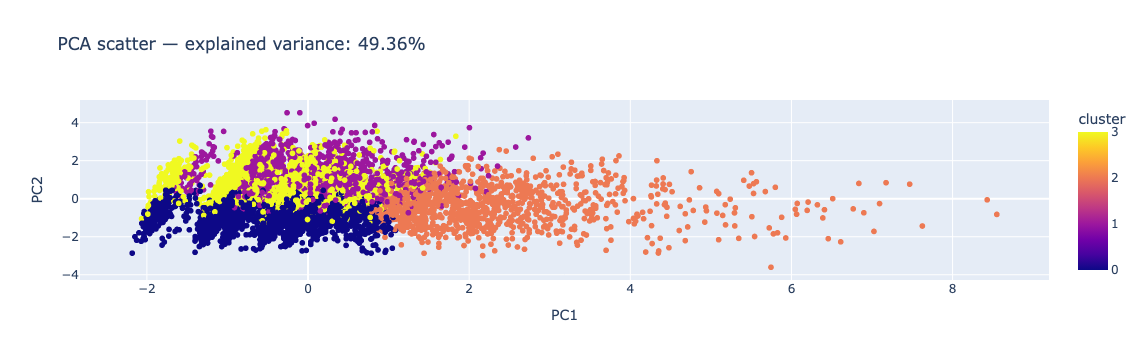

In [18]:
# --- Plotly: Radar / Parallel Coordinates / PCA scatter ---

# Features candidate (usiamo quelle disponibili)
preferred = [
    "mismatch_rate",
    "avg_quality",
    "n_reviews",
    "category_diversity",
    "dominant_size",
    "avg_height",
]
features = [c for c in preferred if c in clustered_df.columns]

fig_radar = plot_cluster_radar(clustered_df, feature_cols=features, title=f"Cluster profiles (normalized) — KMeans k={K}")
fig_radar.show()

fig_pc = plot_cluster_parallel(cluster_profile_labeled, feature_cols=features, title=f"Cluster comparison — Parallel Coordinates (k={K})")
fig_pc.show()

fig_pca = plot_cluster_pca(X_scaled, clustered_df, feature_cols=features, title_prefix="PCA scatter", random_state=42)
fig_pca.show()


### How to Read the Cluster Visualizations

- **Radar chart (normalized 0–1):** highlights at a glance which clusters perform better or worse across each dimension.  
  This is useful for assigning intuitive labels to clusters and linking them to operational levers (e.g., sizing warnings, upsell opportunities, return policies).

- **Parallel coordinates:** shows trade-offs and combinations across multiple features.  
  This helps verify whether a cluster with high mismatch also shows lower perceived quality, or whether more nuanced patterns emerge.

- **PCA scatter (2D):** not intended to “prove” that clusters are perfectly separated, but rather to visualize **overlap and separation** between clusters.  
  If points overlap substantially, the segmentation can still be useful as a **profiling tool**, but it should ideally be validated using downstream KPIs (returns, conversion rate, customer support interactions).